#16.346 PSET 1: Using Runge-Kutta, Orbital Elements, and F&G Series for Orbital Propagation
Asael Acosta

Feb 7, 2026

In [391]:
import matplotlib.pyplot as plt
plt.interactive(False)
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.optimize import fsolve
from scipy.signal import find_peaks
from IPython.display import display

In [412]:
#initial conditions
r_0 = np.array([-5064.7148661, -7879.297593, -6035.892137])
v_0 = np.array([2.103993, -4.564176, 2.507441])

#constants
mu = 398600.64
dt = 10
t_0 = 0
t_f = 8 * 60 * 60

#Plotting trajectories
def traj_fig(coors, title, label):
  fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
  ax.plot(*np.array(coors).T, label=label)
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')
  ax.legend()
  ax.set_title(title)
  return fig, ax

#Plot velocities
def vel_fig(coors, vels, title, label):
  fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
  x = [row[0] for row in coors]
  y = [row[1] for row in coors]
  z = [row[2] for row in coors]
  u = [row[0] for row in vels]
  v = [row[1] for row in vels]
  w = [row[2] for row in vels]

  ax.quiver(x, y, z, u, v, w,
            length=50,
            arrow_length_ratio=0.5,
            pivot='tail',
            color='teal',
            label=label)
  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')
  ax.set_title(title)
  ax.legend()

  return fig, ax

# Problem 1: Plotting Out the Orbital Trajectory via Runge-Kutta


In [399]:
#Functions relevant to Runge-Kutta
def mag(vec):
    return np.sqrt(vec.dot(vec))

def get_v(state):
    return state[1]

def v_dot(state):
    r = state[0]
    norm = mag(r) ** 3
    return np.array([-mu / norm * comp for comp in r])

def RK4(state, dt):
    f_r1 = dt * get_v(state)
    f_v1 = dt * v_dot(state)

    f_r2 = dt * get_v(state + [f_r1/2, f_v1/2])
    f_v2 = dt * v_dot(state + [f_r1/2, f_v1/2])

    f_r3 = dt * get_v(state + [f_r2/2, f_v2/2])
    f_v3 = dt * v_dot(state + [f_r2/2, f_v2/2])

    f_r4 = dt * get_v(state + [f_r3, f_v3])
    f_v4 = dt * v_dot(state + [f_r3, f_v3])

    dr = (f_r1 + 2*f_r2 + 2*f_r3 + f_r4) / 6
    dv = (f_v1 + 2*f_v2 + 2*f_v3 + f_v4) / 6

    return [state[0] + dr, state[1] + dv]

One thing I found interesting with this method of plotting out trajectories taken with RK4 is that they varied slightly every time I ran the code. A chat with Gemini said that even though the math being done is deterministic, quirks of computer architecture can lead to tiny errors appearing in different places and said errors then propagate.

In the case of these trajectories, that means they look a little different whenever my time step is relatively large. When I lowered dt to 1, the issue became far less noticeable.

I'd also like to note that I won't be writing code to plot the velocities of the orbiting body because of its resemblance to the raw trajectory. However, I will still collect the velocity vectors across the assignment and have the function which plots velocity written for future use.

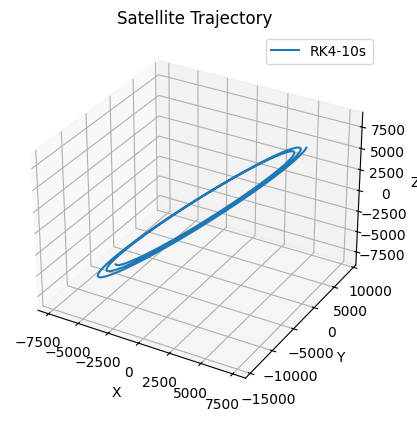

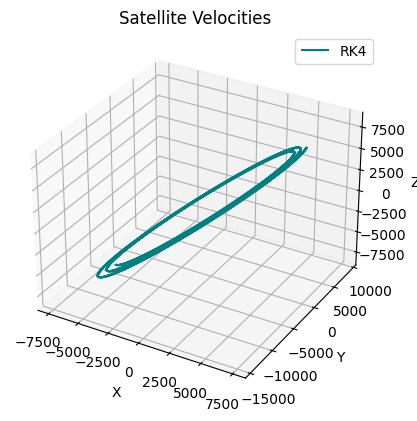

In [413]:
#Plotting the Trajectory
state = np.array([r_0, v_0])
coors_rk = [state[0]]
vels_rk = [state[1]]
for step in range((t_f-t_0)//dt):
    state = RK4(state, dt)
    coors_rk.append(state[0])
    vels_rk.append(state[1])

traj_rk, ax_rk = traj_fig(coors_rk, "Satellite Trajectory", "RK4-10s")
vels_rk, ax_rkvels = vel_fig(coors_rk, vels_rk, "Satellite Velocities", "RK4")
display(traj_rk)
display(vels_rk)

# Problem 2: Using Orbital Elements and F&G Functions

2.1 Converting Initial Conditions to the Relevant Orbital Elements

In [375]:
#specific ang. momentum
h = np.cross(r_0, v_0)

#eccentricity vector
e = 1/mu *( (v_0.dot(v_0) - mu/mag(r_0)) * r_0 - (r_0.dot(v_0)) * v_0 )

#node vector
n = np.array([-h[1], h[0], 0])

#inclination
i = np.arccos(h[2] / mag(h))

#magnitudes
r0_mag = mag(r_0)
v0_mag = mag(v_0)
h_mag = mag(h)
e_mag = mag(e)
n_mag = mag(n)

#Right Ascension of Ascending Node
RAAN_temp = np.arccos(n[0] / n_mag)
RAAN = RAAN_temp if n[1] > 0 else 2*np.pi - RAAN_temp

#Argument of Periapsis
peri_temp = np.arccos(n.dot(e) / (n_mag*e_mag))
ArgPeri = peri_temp if e[2] > 0 else 2*np.pi - peri_temp

#True anomaly
temp_nu = np.arccos(e.dot(r_0)/(e_mag * mag(r_0)))
nu = temp_nu if r_0.dot(v_0) > 0 else 2*np.pi - temp_nu

#Initial Eccentric Anomaly
E_0 = np.arccos((e_mag + np.cos(nu))/(1 + e_mag*np.cos(nu)))

#Semi-major axis
EN = mag(v_0)**2 / 2 - mu / r0_mag
a = -mu / (2*EN)

#Initial Mean Anomaly
mean_motion = np.sqrt(mu / a**3)
M_0 = E_0 - e_mag*np.sin(E_0)

2.2 Converting the Orbital Elements Back to the Initial Conditions

In [376]:
#To perifocal
x = a * (np.cos(E_0) - e_mag)
y = a * np.sqrt(1 - e_mag ** 2) * np.sin(E_0)
xdot = -np.sqrt(mu*a)/r0_mag * np.sin(E_0)
ydot = np.sqrt(mu*a*(1-e_mag**2))/r0_mag * np.cos(E_0)

r_peri = np.array([x,y,0])
v_peri = np.array([xdot, ydot, 0])


#Rotation Matrix
cR = np.cos(RAAN)
sR = np.sin(RAAN)
cA = np.cos(ArgPeri)
sA = np.sin(ArgPeri)
cI = np.cos(i)
sI = np.sin(i)

rotMat = np.array([[cR*cA-sR*sA*sI, -cR*sA-sR*cA*cI, sR*sI],
                   [sR*cA+cR*sA*sI, -sR*sA-cR*cA*cI, -cR*sI],
                   [    sA*sI,         cA*sI,         cI]])

#Compare the re-rotated perifocal vectors with the initial conditions
print(all(np.isclose(r_0, np.matmul(rotMat, r_peri.T))))
print(all(np.isclose(v_0, np.matmul(rotMat, v_peri.T))))

True
True


2.3.1 Using Orbital Elements to Determine Position and Velocity

In [377]:
#return an equation that zeroes out when E is correctly chosen
def E_eq(M):
  def M_func(E):
    return E - e_mag*np.sin(E) - M
  return M_func

def calc_E(t):
  M = M_0 + mean_motion*(t - t_0)
  #numerically solve for E from M
  M_eq = E_eq(M)
  return fsolve(M_eq, M)[0]

def r_oe(t):
  E = calc_E(t)
  x = a * (np.cos(E) - e_mag)
  y = a * np.sqrt(1 - e_mag ** 2) * np.sin(E)
  return np.array([x,y,0])

def v_oe(t):
  E = calc_E(t)
  xdot = -np.sqrt(mu*a)/r0_mag * np.sin(E)
  ydot = np.sqrt(mu*a*(1-e_mag**2))/r0_mag * np.cos(E)
  return np.array([xdot, ydot, 0])

2.3.2 Plotting Orbital Trajectories Determined via Orbital Elements

As expected, if the coordinates collected in the perifocal matrix are plotted out, they're parallel to the xy plane. This checks out with the definition of the perifocal reference frame.

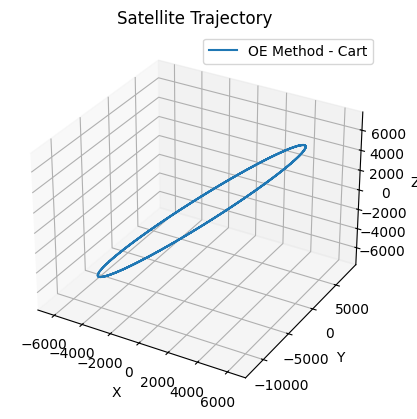

In [414]:
#coors_oe = [r_peri]
coors_rot = [r_0]
v_rot = [v_0]

#plot out the trajectory before and after rotation
for step in range((t_f-t_0)//dt):
    r_peri = r_oe(step*dt)
    v_peri = v_oe(step*dt)
    #coors_oe.append(r_peri)
    coors_rot.append(np.matmul(rotMat, r_peri))
    v_rot.append(np.matmul(rotMat, v_peri))

traj_rot, ax_rot = traj_fig(coors_rot, "Satellite Trajectory", "OE Method - Cart")
#traj_oe, ax_oe = traj_fig(coors_oe, "Satellite Trajectory", "OE Method - Peri")
display(traj_rot)
#display(traj_oe)

2.4 Propagating an Orbit via F & G Functions

I'd like to note that although several variables have already been defined earlier, I'll use the new vector identity definitions to redeclare them to demonstrate the geometry being extracted without knowledge of the apoapsis/periapsis. However, there's no need to rederive constants like a because those are derived independently from a vector or geometric understanding of an orbit.

In [379]:
#defined for convenience
sqrt_mu = np.sqrt(mu)

#Eccentricity
e = np.cross(v_0, h)/mu - r_0/r0_mag
e_mag = mag(e)

#Semi-Latus Rectum
p = a * (1 - e_mag**2)

#Initial Radial Velocity Parameter
sigma_0 = r_0.dot(v_0) / sqrt_mu

#Initial Eccentric Anomaly
E_0 = np.arctan2(sigma_0/np.sqrt(a), 1-r0_mag/a)

In [416]:
def theta(E):
  sin_comp = np.sqrt(1+e_mag) * np.sin(E/2)
  cos_comp = np.sqrt(1-e_mag) * np.cos(E/2)
  return 2*np.arctan2(sin_comp, cos_comp)

def theta_tilde(E):
  return theta(E) - theta(E_0)

def r_mag(dtheta):
  denom = r0_mag + (p-r0_mag)*np.cos(dtheta) - sigma_0*np.sqrt(p)*np.sin(dtheta)
  return p*r0_mag / denom

def F(r_mag, dtheta):
  return 1 - r_mag/p * (1-np.cos(dtheta))

def G(r_mag, dtheta):
  return r_mag*r0_mag/h_mag * np.sin(dtheta)

def Fdot(dtheta):
  coeff = sqrt_mu/(r0_mag*p)
  exprn = sigma_0*(1-np.cos(dtheta)) - np.sqrt(p)*np.sin(dtheta)
  return coeff * exprn

def Gdot(dtheta):
  return 1 - r0_mag/p * (1-np.cos(dtheta))

def r_fg(t):
  E = calc_E(t)
  deltheta = theta_tilde(E)
  r_scal = r_mag(deltheta)
  F_ = F(r_scal, deltheta)
  G_ = G(r_scal, deltheta)
  return F_*r_0 + G_*v_0

def v_fg(t):
  E = calc_E(t)
  deltheta = theta_tilde(E)
  r_scal = r_mag(deltheta)
  Fdot = F(r_scal, deltheta)
  Gdot = G(r_scal, deltheta)
  return Fdot*r_0 + Gdot*v_0

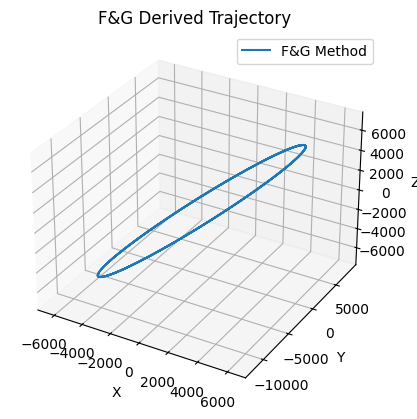

In [418]:
coors_fg = [r_0]
vels_fg = [v_0]

for step in range((t_f-t_0)//dt):
  coors_fg.append(r_fg(step * dt))
  vels_fg.append(v_fg(step*dt))

traj_fg, ax_fg = traj_fig(coors_fg, "F&G Derived Trajectory", "F&G Method")
display(traj_fg)

2.5.1 Problem 1 Comparison

The two trajectories that are derived from orbital elements are visually identical, which checks out with the fact that their numerical errors don't stack up the way RK4's do. At each time step, they have small numerical errors, but these errors are local to each time step and don't inform the next step.

Comparing the plots from Problems 1 and 2, they do look similar, but the plot from Problem 1 is visually distinct from an ellipse. This can be attributed time steps being integrated over being fairly large, causing RK4 to diverge noticeably as its errors accumulate. However, I did notice that when the time steps were lowered down to a single second, the error visually vanished and all 3 methods produced visually identical plots.

In [419]:
#RK4 with smaller time steps
state = [r_0, v_0]
coors_dt = [state[0]]
dt_reduced = 1
for step in range((t_f-t_0)//dt_reduced):
    state = RK4(state, dt_reduced)
    coors_dt.append(state[0])

traj_rkdt, ax_rkdt = traj_fig(coors_dt, "Satellite Trajectory", "RK4-1s")

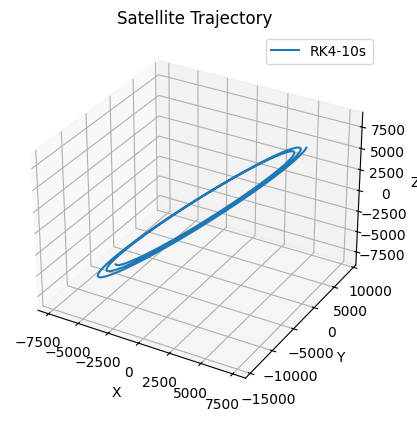

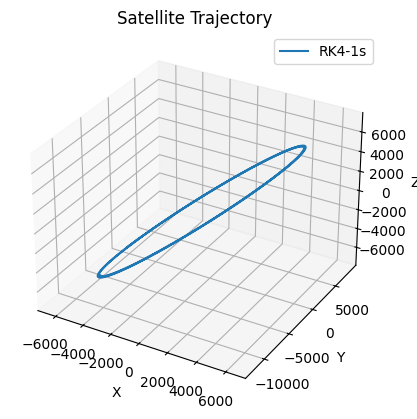

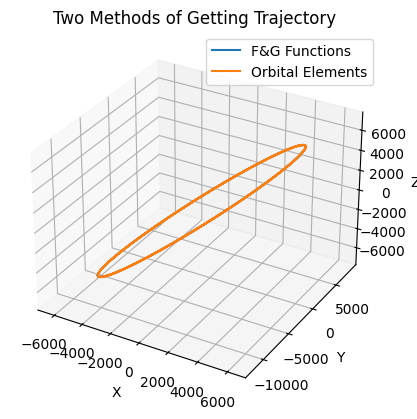

In [420]:
#superimpose the two methods of drawing out the trajectory in one plot
fg_and_oe, ax_fgoe = traj_fig(coors_fg, "Two Methods of Getting Trajectory", "F&G Functions")
ax_fgoe.plot(*np.array(coors_rot).T,label="Orbital Elements")
ax_fgoe.legend()

#redisplay the different trajectories for comparison
display(traj_rk)
display(traj_rkdt)
display(fg_and_oe)

2.5.2 Error Approximation and Analysis

As can be seen from the plot produced by the cell below, the error of the RK4 scheme doesn't perfectly grow like a polynomial. It has these oscillations stemming from the RK4 scheme slightly missing the geometry of the system over time, but still getting closer on small time scales.

It's known that because RK4 is a 4th order method, the cumulative effect on a periodic system like an orbit is  

$\epsilon (T) \simeq \Phi \cdot h^4 \cdot T^2$

Where $\Phi$ is a costant, $h^4$ is the step size and $T^2$ is the elapsed time. We can solve for $\Phi$ algebraically by choosing one of the local maxima, which would comprise the envelope of this graph and thus bound the error beneath it, and solving for it algebraically.

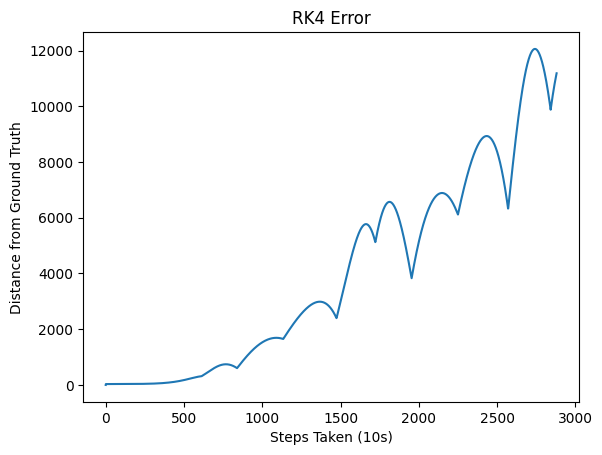

In [369]:
def plot_diffs(cor1, cor2, title='', x='', y=''):
  assert np.array(cor1).shape == np.array(cor2).shape
  diffs = [np.abs(np.array(cor1[i]) - cor2[i]).mean() for i in range(len(cor1))]
  fig, ax = plt.subplots()
  ax.plot(diffs)
  ax.set_title(title)
  ax.set_xlabel(x)
  ax.set_ylabel(y)
  return fig, diffs

#collect the figure and data used to plot it
error_10s, errors = plot_diffs(coors_fg, coors_rk,
                        'RK4 Error', 'Steps Taken (10s)',
                        "Distance from Ground Truth")
display(error_10s)

2.5.2 (Cont.) Using SciPy, we can locate one of these maxima arbitrarily and do the math to comput what $\Phi$ should be. After doing so, we can predict the error expected of the RK4 scheme after 8 hours of orbit with the ground truth orbit derived via the orbital elements.

The error approximation turns out to be fairly accurate, coming to be ~19% off of the true error for a few different trials of reinitializing the RK4 trajectory. It makes sense for the asymptotic prediction to line up well because enough time steps have passed for the secular drift to dominate over the oscillations. The oscillations themselves occur because at different points in the orbit, it's easier/harder to calculate the correct trajectory. For example, when near the apoapsis, the acceleration of the orbiting body is quite small, so errors aren't punished as much. However, when approaching the periapsis, where acceleration is greatest, small errors are compounded significantly.

In [370]:
#find_peaks also returns a dictionary depending on extra params
#but those aren't relevant for this analysis
peak_locs, dummy_var = find_peaks(errors)
peak_idx = peak_locs[-1]
peak = errors[peak_idx]
Phi = peak / (dt**4 * (10*peak_idx)**2)

#Calculating and comparing errors
pred_error = Phi * dt**4 * t_f**2
true_error = np.abs(np.array(coors_rk[-1]) - coors_fg[-1]).mean()
fract_diff = np.abs(pred_error - true_error) / true_error
print(fract_diff)

0.1894383939528682
